# IS 4487 Assignment 11: Predicting Airbnb Prices with Regression

In this assignment, you will:
- Load the Airbnb dataset you cleaned and transformed in Assignment 7
- Build a linear regression model to predict listing price
- Interpret which features most affect price
- Try to improve your model using only the most impactful predictors
- Practice explaining your findings to a business audience like a host, pricing strategist, or city partner

## Why This Matters

Pricing is one of the most important levers for hosts and Airbnb’s business teams. Understanding what drives price — and being able to predict it accurately — helps improve search results, revenue management, and guest satisfaction.

This assignment gives you hands-on practice turning a cleaned dataset into a predictive model. You’ll focus not just on code, but on what the results mean and how you’d communicate them to stakeholders.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_11_regression.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


## 1. Load Your Transformed Airbnb Dataset

**Business framing:**  
Before building any models, we must start with clean, prepared data. In Assignment 7, you exported a cleaned version of your Airbnb dataset. You’ll now import that file for analysis.

### Do the following:
- Import your CSV file called `cleaned_airbnb_data_7.csv`.   (Note: If you had significant errors with assignment 7, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)
- Use `pandas` to load and preview the dataset


In [2]:
df = pd.read_csv('cleaned_airbnb_data_7.csv')

print('Rows, columns:', df.shape)
df.head()

Rows, columns: (4939, 63)


,id,name,host_id,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_is_superhost,host_listings_count,...,price_zscore,price_log_zscore,review_activity,price_per_person,long_stay_listing,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room,review_activity_ordinal
0,360,Denver’s Peaceful Oasis for Travel Nurses & No...,666,17,11,15.0,5.0,"Denver, CO",1,2,...,-0.096805,-0.667229,High,53.175000,0,True,False,False,False,2
1,364,Lodo / RiNo LOFT via airport train,783,17,11,15.0,6.0,"Mesa, AZ",0,1,...,-0.139020,-2.170639,High,10.783333,1,True,False,False,False,2
2,592,private,933,17,11,15.0,5.0,"Denver, CO",1,1,...,-0.111837,-1.029432,High,40.000000,0,False,False,True,False,2
3,686,Alexandra's Queen Bed Room Long-term Rental Only,990,17,11,15.0,5.0,"Denver, CO",0,1,...,-0.132220,-1.777647,High,44.270000,1,False,False,True,False,2
4,1940,"Baker Studio Pet-friendly, Walkable, Patio",2150,17,10,9.0,7.0,"Denver, CO",1,2,...,-0.048104,0.085280,High,95.860000,0,True,False,False,False,2


### Reflection: 
1. What business information does the dataset include?
2. How many rows and columns are present?

### ✍️ Your Response: 🔧
1. It's Denver Airbnb listings. Each row has host details (superhost status, number of listings, time hosting), location, the property (room type, guests, bedrooms, bathrooms, beds), price and minimum and maximum nights, availability, reviews and ratings, estimated bookings and revenue, and the license. It also has the columns I added in Assignment 7, like `price_per_person`, `long_stay_listing` and the room type dummies.

2. 4,939 rows and 63 columns.

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
Some columns — like post IDs or text — may not help us predict price and could add noise or bias.

### Do the following:
- Drop columns like `post_id`, `title`, `descr`, `details`, and `address` if they’re still in your dataset

In [3]:
drop_cols = [
    # IDs and free text
    'id', 'host_id', 'name', 'host_location', 'license', 'bathrooms_text',
    # too many categories to encode here (77 neighborhoods, 38 property types)
    'neighbourhood_cleansed', 'property_type',
    # dates
    'first_review', 'last_review',
    # built from price, so they would give the answer away
    'price_log', 'price_zscore', 'price_log_zscore', 'price_per_person', 'estimated_revenue_l365d',
    # extra versions of columns that stay in
    'availability_30', 'availability_60', 'availability_90', 'availability_eoy',
    'number_of_reviews_ltm', 'number_of_reviews_l30d', 'number_of_reviews_ly',
    'reviews_minmax', 'review_activity', 'calculated_host_listings_count',
    'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms',
    'calculated_host_listings_count_shared_rooms', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    # 1 on every row that has a value
    'has_availability',
    # left out so the other room types are compared against entire homes
    'room_type_Entire home/apt',
]
df_model = df.drop(columns=drop_cols)
print('Columns before:', df.shape[1], ' after:', df_model.shape[1])

# Rows: a listing with no price can't be used, and the 9 listings over $2,000 a night
# (including the $110,616 one) would drown out everything else
print('\nListings with no price:', df_model['price'].isna().sum())
print('Listings over $2,000:', (df_model['price'] > 2000).sum())
df_model = df_model[df_model['price'] <= 2000]

missing = df_model.isna().sum()
print('\nMissing values by column:')
print(missing[missing > 0])
print('Listings missing at least one value:', df_model.isna().any(axis=1).sum())
df_model = df_model.dropna()

print('\nRows left:', len(df_model))

Columns before: 63  after: 27

Listings with no price: 688
Listings over $2,000: 9

Missing values by column:
bedrooms                476
beds                    222
minimum_nights            1
maximum_nights            1
review_scores_rating    517
reviews_per_month       517
dtype: int64
Listings missing at least one value: 1108

Rows left: 3134


### Reflection: 
1. What columns did you drop, and why?
2. What risks might occur if you included them in your model?

### ✍️ Your Response: 🔧
1. The columns named in the instructions come from the rent data and aren't in this file, so I dropped the Airbnb versions, 36 columns in all. That means IDs and free text like `name` and `license`, neighborhood and property type (too many categories to encode), review dates, the five columns built from price, and extra versions of columns that stay in, like availability over different windows. I also dropped `has_availability` since it's always 1, and the entire home dummy so the other room types compare against it. For rows, I removed 688 listings with no price, 9 over \$2,000 a night, and 1,108 missing something else, mostly no reviews yet or no bedroom count. That left 3,134 listings.

2. The price columns would give the answer away. `price_zscore` is just price rescaled, so the model would look almost perfect and be useless for a listing without a price. Repeated columns split one effect across several coefficients, sometimes with opposite signs. And the \$110,616 listing would have pulled the whole fit toward itself.

## 3. Explore Relationships Between Numeric Features

**Business framing:**  
Understanding how features relate to each other — and to the target — helps guide feature selection and modeling.

### Do the following:
- Generate a correlation matrix
- Identify which variables are strongly related to `price`

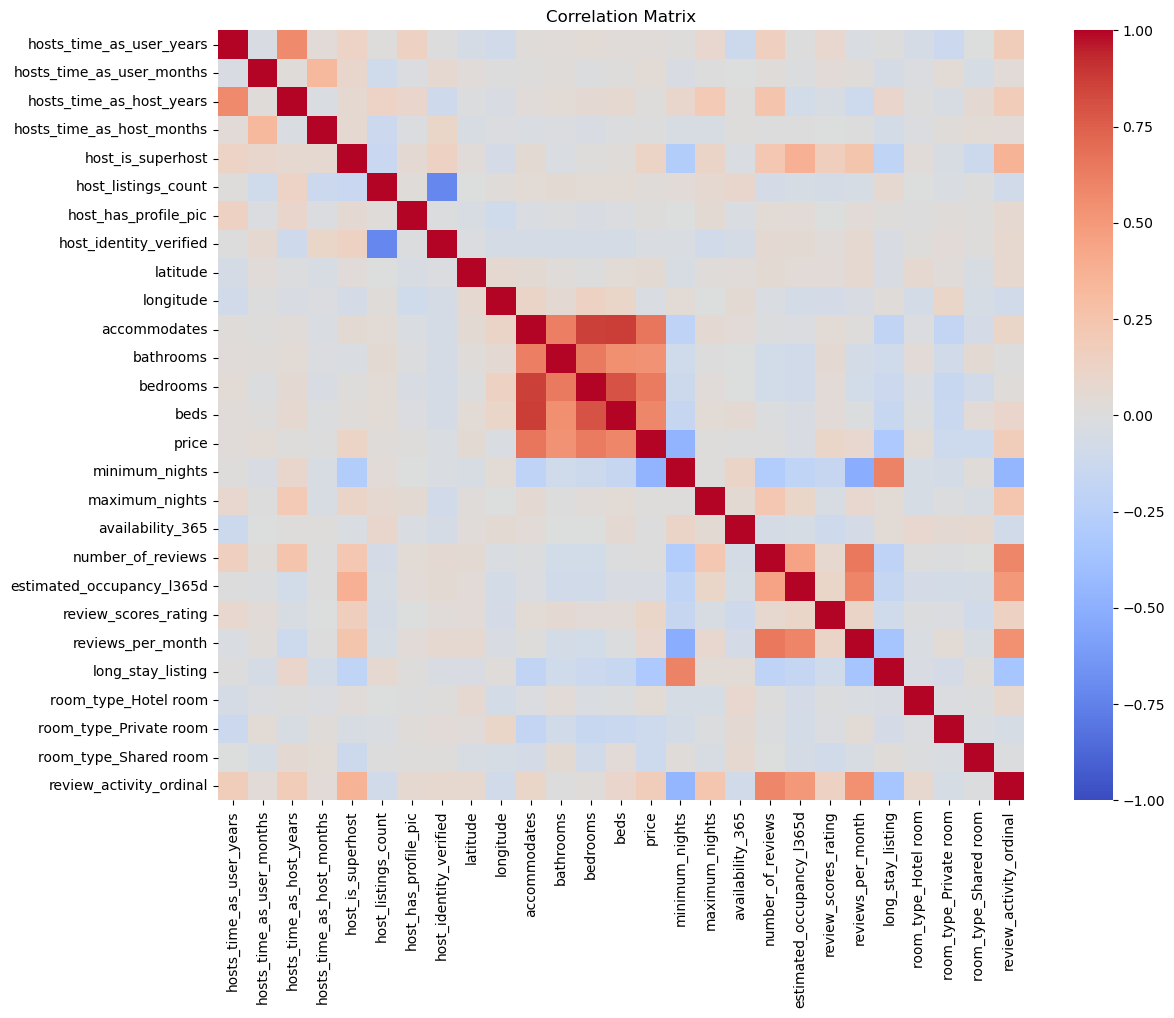

Correlation with price:
accommodates                 0.658
bedrooms                     0.635
beds                         0.590
bathrooms                    0.538
review_activity_ordinal      0.175
host_is_superhost            0.122
review_scores_rating         0.108
reviews_per_month            0.081
latitude                     0.053
hosts_time_as_user_months    0.045
room_type_Hotel room         0.040
hosts_time_as_user_years     0.026
host_listings_count          0.023
host_has_profile_pic         0.015
hosts_time_as_host_years     0.011
maximum_nights               0.010
availability_365             0.007
number_of_reviews            0.004
hosts_time_as_host_months    0.003
host_identity_verified      -0.027
longitude                   -0.028
estimated_occupancy_l365d   -0.038
room_type_Private room      -0.113
room_type_Shared room       -0.115
long_stay_listing           -0.313
minimum_nights              -0.473
Name: price, dtype: float64


In [4]:
corr = df_model.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

print('Correlation with price:')
print(corr['price'].drop('price').sort_values(ascending=False).round(3))

### Reflection: 
1. Which variables had the strongest positive or negative correlation with price?
2. Which variables might be useful predictors?

### ✍️ Your Response: 🔧
1. The strongest positive correlations are `accommodates` (0.658), `bedrooms` (0.635), `beds` (0.590) and `bathrooms` (0.538), so bigger places cost more. The strongest negative are `minimum_nights` (-0.473) and `long_stay_listing` (-0.313), so listings that require longer stays charge less per night.

2. Size, minimum nights and room type. The size columns overlap a lot with each other (the dark red block in the heatmap), so they won't all add something new. Review scores and superhost status are only around 0.11 to 0.12, and availability and time hosting are close to zero.

## 4. Define Features and Target Variable

**Business framing:**  
To build a regression model, you need to define what you’re predicting (target) and what you’re using to make that prediction (features).

### Do the following:
- Set `price` as your target variable
- Remove `price` from your predictors

In [5]:
y = df_model['price']
X = df_model.drop(columns='price')

print('Number of features:', X.shape[1])
print(list(X.columns))

Number of features: 26
['hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_is_superhost', 'host_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'estimated_occupancy_l365d', 'review_scores_rating', 'reviews_per_month', 'long_stay_listing', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'review_activity_ordinal']


### Reflection: 
1. What features are you using?
2. Why is this a regression problem and not a classification problem?

### ✍️ Your Response: 🔧
1. All 26 columns left after step 2. The main groups are size, minimum and maximum nights, availability, reviews, host details, location, estimated bookings and room type.

2. Price is a dollar amount that can be any number, so the model has to predict a number. Classification predicts a category, like the affordable yes or no in Lab 10.

## 5. Split Data into Training and Testing Sets

### Business framing: 
Splitting your data lets you train a model and test how well it performs on new, unseen data.

### Do the following:
- Use `train_test_split()` to split into 80% training, 20% testing



In [6]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale so the coefficients in step 8 can be compared. The scaler only learns from training rows.
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))

Training rows: 2507
Testing rows: 627


## 6. Fit a Linear Regression Model

### Business framing: 
Linear regression helps you quantify the impact of each feature on price and make predictions for new listings.

### Do the following:
- Fit a linear regression model to your training data
- Use it to predict prices for the test set



In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
pd.DataFrame({'actual_price': y_test, 'predicted_price': y_pred.round(2)}).head()

,actual_price,predicted_price
2653,112.19,104.48
822,246.50,283.11
696,474.00,462.32
1941,77.06,79.02
1644,105.94,33.89


## 7. Evaluate Model Performance

### Business framing:  
A good model should make accurate predictions. We’ll use Mean Squared Error (MSE) and R² to evaluate how close our predictions were to the actual prices.

### Do the following:
- Print MSE and R² score for your model

In [8]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:,.0f}')
print(f'R-squared: {r2:.3f}')
print(f'Square root of MSE: ${mse ** 0.5:,.0f}')
print(f'Median price in the test set: ${y_test.median():,.0f}')

MSE: 15,211
R-squared: 0.681
Square root of MSE: $123
Median price in the test set: $211


### Reflection: 
1. What is your R² score? How well does your model explain price variation?
2. Is your MSE large or small? What could you do to improve it?

### ✍️ Your Response: 🔧
1. R-squared is 0.681, so the model explains about 68% of the variation in nightly price on the test listings. That's decent for a straight-line model that doesn't know the neighborhood, but about a third of the variation is left unexplained.

2. MSE is 15,211, but that's in squared dollars. The square root is a typical miss of about \$123 on a median price of \$211, which is big. I'd add location back by grouping neighborhoods, predict the log of price since prices are skewed, and fill in missing values instead of dropping 1,108 listings.

## 8. Interpret Model Coefficients

### Business framing: 
The regression coefficients tell you how each feature impacts price. This can help Airbnb guide hosts and partners.

### Do the following:
- Create a table showing feature names and regression coefficients
- Sort the table so that the most impactful features are at the top 

In [9]:
coefficients = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_})
coefficients = coefficients.sort_values('coefficient', key=abs, ascending=False)
coefficients.round(2)

,feature,coefficient
14,minimum_nights,-94.63
12,bedrooms,54.92
11,bathrooms,39.15
10,accommodates,37.35
24,room_type_Shared room,-22.81
9,longitude,-18.51
20,reviews_per_month,-14.46
18,estimated_occupancy_l365d,-12.84
13,beds,12.66
16,availability_365,12.11


### Reflection: 
1. Which features increased price the most?
2. Were any surprisingly negative?
3. What business insight could you draw from this?

### ✍️ Your Response: 🔧
1. `bedrooms` (54.92), `bathrooms` (39.15) and `accommodates` (37.35). Since the features were scaled, one standard deviation more bedrooms adds about \$55 a night with everything else held the same.

2. `reviews_per_month` (-14.46), `estimated_occupancy_l365d` (-12.84) and `number_of_reviews` (-7.81). I expected popular listings to charge more, but cheaper listings probably just get booked more, so price is driving the bookings. `longitude` (-18.51) means listings farther east are cheaper. `minimum_nights` (-94.63) is the biggest overall, which fits what I found about 30-night rentals in Assignment 7.

3. Price mostly comes down to size and minimum stay. Hosts can't add a bedroom, but they do set the minimum stay, so a host moving to monthly stays should expect a lower nightly rate. Ratings barely move price (0.82), so a better rating alone isn't a reason to charge more.

## 9. Try to Improve the Linear Regression Model

### Business framing:
The first version of your model included all available features — but not all features are equally useful. Removing weak or noisy predictors can often improve performance and interpretation.

### Do the following:
1. Choose your top 3–5 features with the strongest absolute coefficients
2. Rebuild the regression model using just those features
3. Compare MSE and R² between the baseline and refined model

In [10]:
top_features = coefficients['feature'].head(5).tolist()
print('Top 5 features:', top_features)

refined_model = LinearRegression()
refined_model.fit(X_train[top_features], y_train)
y_pred_refined = refined_model.predict(X_test[top_features])

mse_refined = mean_squared_error(y_test, y_pred_refined)
r2_refined = r2_score(y_test, y_pred_refined)

pd.DataFrame({
    'model': ['Baseline (all features)', 'Refined (top 5)'],
    'features': [X.shape[1], len(top_features)],
    'MSE': [round(mse), round(mse_refined)],
    'R-squared': [round(r2, 3), round(r2_refined, 3)],
})

Top 5 features: ['minimum_nights', 'bedrooms', 'bathrooms', 'accommodates', 'room_type_Shared room']


,model,features,MSE,R-squared
0,Baseline (all features),26,15211,0.681
1,Refined (top 5),5,16120,0.662


### Reflection: 
1. What features did you keep in the refined model, and why?
2. Did model performance improve? Why or why not?
3. Which model would you recommend to stakeholders?
4. How does this relate to your customized learning outcome you created in canvas?

### ✍️ Your Response: 🔧
1. `minimum_nights`, `bedrooms`, `bathrooms`, `accommodates` and `room_type_Shared room`. They had the five biggest coefficients by absolute value, and because the features were scaled, that means they move price the most.

2. No. R-squared fell from 0.681 to 0.662 and MSE rose from 15,211 to 16,120. The 21 features I removed each helped a little, and together they were worth about 2 points of R-squared. Five features still get most of the way there.

3. The refined model. A host can use it with five things they already know about their place, and it only loses about 2 points of R-squared. For Airbnb's own pricing tool, the baseline is a bit more accurate.

4. My first outcome is using Python to clean data, run basic models and judge whether a change actually worked. Comparing both models on the same test listings is the same check I'd run on a campaign change. Change one thing, keep the rest the same, and let the numbers decide.

## 10. Reflect and Recommend

### Business framing:  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### Reflection: 
1. What business question did your model help answer?
2. What would you recommend to Airbnb or its hosts?
3. What could you do next to improve this model or make it more useful?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. What drives the nightly price of a Denver Airbnb listing, and how well can the listing details predict it? Size and minimum stay explain most of it, and the model gets about 68% of the variation.

2. Hosts should price from size first, and anyone moving to 30-night minimums should plan for a lower nightly rate. Reviews alone won't push price up. Airbnb could base pricing suggestions on size and minimum stay, and flag listings priced far above what their size predicts, like the \$110,616 one.

3. Group the neighborhoods into a few areas and add them back, predict the log of price, and try separate models for nightly and long stays. I'd also keep the 1,108 dropped listings by filling in missing values, like 0 reviews per month for listings with no reviews.

4. My second outcome is turning results into recommendations a team can use while handling bias and the limits of the data. Most of the 1,108 listings I dropped had no reviews yet (517) or no bedroom count (476), so the model leans toward established listings and may not price new hosts well. I'd also want Airbnb to check that its suggestions come from the listing itself, since something like whether the host has a profile picture shouldn't change the price.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [11]:
!jupyter nbconvert --to html "assignment_11_regression.ipynb"

[NbConvertApp] Converting notebook assignment_11_regression.ipynb to html


[NbConvertApp] Writing 323827 bytes to assignment_11_regression.html
